In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from textblob import TextBlob

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [2]:
data = {
    "review": [
        "This product is amazing!",
        "Worst experience ever",
        "It is okay, not great",
        "Absolutely fantastic service",
        "I hate this item",
        "Very good quality",
        "Not bad, could be better"
    ]
}

df = pd.DataFrame(data)
df.head()

,review
0,This product is amazing!
1,Worst experience ever
2,"It is okay, not great"
3,Absolutely fantastic service
4,I hate this item


In [3]:
df.dropna(inplace=True)

In [4]:
df['review'] = df['review'].str.lower()

In [5]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['review'].apply(get_sentiment)

df.head()

,review,sentiment
0,this product is amazing!,Positive
1,worst experience ever,Negative
2,"it is okay, not great",Positive
3,absolutely fantastic service,Positive
4,i hate this item,Negative


In [6]:
df['sentiment'].value_counts()

sentiment
Positive    5
Negative    2
Name: count, dtype: int64

In [7]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['review'])
y = df['sentiment']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [10]:
y_pred = model.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.0

Classification Report:

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       1.0
    Positive       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0



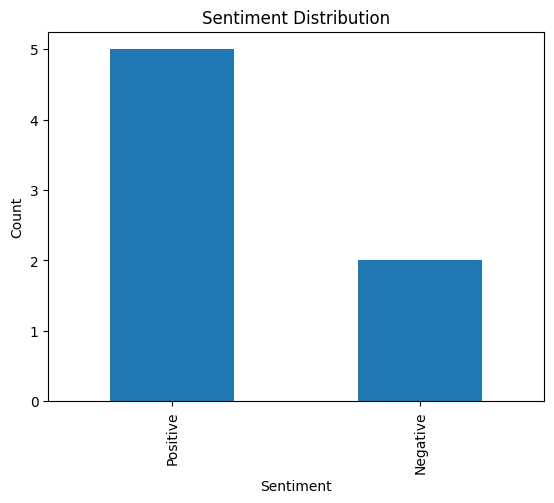

In [12]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()